In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from scipy.spatial import distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [3]:
class brain(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers=2, num_layers_sleep=2):
        super(brain, self).__init__()

        self.rnn = nn.RNN(input_size+sleep_output_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_rnn = nn.RNN(1, hidden_sleep_size, num_layers_sleep, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, sleep_output_size)
        # self.fc = nn.Linear(hidden_wake_size, 15)
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))
        self.sleep_output_size = sleep_output_size

    def forward(self, x, x_=None, hw=None, hs=None, sleep=False):
        # print(x.shape, 'x')
        if sleep:
            if hs == None:
                out, hs = self.sleep_rnn(x_)
            else:
                out, hs = self.sleep_rnn(x_, hs)
            # print(out.shape)
            sleep_out = self.sleep_fc(out)
        else:
            sleep_out = torch.zeros((1,x.size(1),self.sleep_output_size))
            
        # print(x.size())
        x = torch.cat((x,sleep_out), dim=2)
        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        # out_ = self.fc(out) 
        out = self.wake_fc(out[:,-1,:])

        if sleep:
            return out, hw, hs
        else:
            return out, hw


In [4]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [5]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [6]:
class place_cells(nn.Module):
    def __init__(self, input_size, output_size):
        super(place_cells, self).__init__()
        
        self.linear1 = nn.utils.weight_norm(nn.Linear(input_size, output_size))

    def forward(self, x):
        out = self.linear1(x)

        return out

In [7]:
### initial training ###
total_samples = 40000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 40
hidden_sleep_size = 10
sleep_output_size = 5
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = len(tokens)*working_memory
lr = 4e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)

data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = brain(input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = network1(X)
    else:
        predicted_y, hidden = network1(X, hw=mem)
    
    # print(predicted_y.shape, y.shape)
    loss = criterion(predicted_y, y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')


Iter : 1001, loss: 2.0502, accuracy: 0.2340
Iter : 2001, loss: 1.9090, accuracy: 0.2500
Iter : 3001, loss: 1.6229, accuracy: 0.3500
Iter : 4001, loss: 2.3474, accuracy: 0.5230
Iter : 5001, loss: 1.9309, accuracy: 0.6060
Iter : 6001, loss: 1.8313, accuracy: 0.6630
Iter : 7001, loss: 1.9001, accuracy: 0.6580
Iter : 8001, loss: 1.4424, accuracy: 0.6650
Iter : 9001, loss: 1.1788, accuracy: 0.6710
Iter : 10001, loss: 1.1747, accuracy: 0.6740
Iter : 11001, loss: 1.5379, accuracy: 0.6610
Iter : 12001, loss: 2.2130, accuracy: 0.6850
Iter : 13001, loss: 2.6085, accuracy: 0.6550
Iter : 14001, loss: 1.9332, accuracy: 0.6550
Iter : 15001, loss: 2.2143, accuracy: 0.6760
Iter : 16001, loss: 1.6621, accuracy: 0.6550
Iter : 17001, loss: 1.5520, accuracy: 0.6750
Iter : 18001, loss: 2.0300, accuracy: 0.6610
Iter : 19001, loss: 1.6921, accuracy: 0.6530
Iter : 20001, loss: 2.2109, accuracy: 0.6580
Iter : 21001, loss: 1.9699, accuracy: 0.6690
Iter : 22001, loss: 1.5649, accuracy: 0.6690
Iter : 23001, loss:

In [8]:
def mse_contrastive_loss(pivot, pos, neg, repel_margin=5.0):
    pull_loss = nn.functional.mse_loss(pivot, pos)
    d_neg = ((pivot.unsqueeze(1) - neg) ** 2).sum(dim=-1) 
    repel_loss = torch.relu(repel_margin - d_neg).mean()

    return pull_loss + repel_loss


In [9]:
total_samples = 100000
idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
counts = []
seq = ''
seq_ = ''

place_cell = place_cells(hidden_wake_size, 10)
optimizer = torch.optim.SGD(place_cell.parameters(), lr=1e-3, momentum=0.95)
criterion = mse_contrastive_loss

for jj in range(total_samples):
    with torch.no_grad():
        if jj == 0:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1))
        else:
            prev_hidden = hidden_state.clone()
            hidden_state_neg = hidden_state + 0.5 * torch.randn(hidden_state.shape)
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hidden_state)

        X_hat = torch.nn.functional.softmax(X_hat_, dim=1)
        dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()

        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)
        seq = seq + tokens[idx]

        #hidden_state_neg = hidden_state + 0.01 * torch.randn(hidden_state.shape)
        #X_hat_neg = 1-torch.nn.functional.softmax(X_hat_, dim=1)
        #dist_categ = torch.distributions.Categorical(probs=X_hat_neg.reshape(-1))
        #idx = 6#X_hat_neg.argmax()

        #X_hat_neg = torch.zeros(len(tokens),dtype=torch.float32)
        #X_hat_neg[idx] = 1.0
        #X_hat_neg = X_hat_neg.reshape(1,1,-1)
        #seq_ = seq_ + tokens[idx]
        
        #_, hidden_state_neg = network1(X_hat.reshape(1,1,-1), hidden_state)

    if jj != 0:
        
        optimizer.zero_grad()

        out1 = place_cell(hidden_state.reshape(-1))
        out2 = place_cell(prev_hidden.reshape(-1))
        out_neg = place_cell(hidden_state_neg.reshape(-1))
        
        loss = criterion(out1,out2,out_neg)
        loss.backward(retain_graph=True)
        optimizer.step()

    if jj%10000==0:
        print('Loss',loss.item())
    
        

/opt/anaconda3/envs/efri/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loss 0.006660049315541983
Loss 3.703973305846375e-08
Loss 6.458123098795898e-12
Loss 3.8775269217694586e-07
Loss 7.744915548734549e-14
Loss 1.3891109942008872e-13
Loss 1.4246381309888922e-13
Loss 2.25952584550701e-13
Loss 1.6413537467108857e-13
Loss 5.446310178021385e-13


In [10]:
torch.matmul(hidden_state.reshape(-1), hidden_state.reshape(-1).T)

/var/folders/_7/jy1bxm8x25zgqldfzz7cqv8r0000gn/T/ipykernel_7387/2254686266.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729646995093/work/aten/src/ATen/native/TensorShape.cpp:3687.)
  torch.matmul(hidden_state.reshape(-1), hidden_state.reshape(-1).T)


tensor(6.8056)

In [16]:
total_samples = 1
idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
counts = []
seq = ''

for jj in range(total_samples):
    with torch.no_grad():
        if jj == 0:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1))
        else:
            prev_hidden = hidden_state.clone()
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hidden_state)

        print(X_hat, 'input')
        X_hat = torch.nn.functional.softmax(X_hat_, dim=1)
        print(X_hat_, 'output')
        
        dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()

        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)
        seq = seq + tokens[idx]

    
        if jj != 0:
            out1 = place_cell(hidden_state.reshape(-1))
            out2 = place_cell(prev_hidden.reshape(-1))
            
            print(out1,out2,torch.sum(out1-out2), seq[-1], seq[-2])
            
    
    
        

tensor([0., 0., 0., 1., 0., 0., 0.]) input
tensor([[-2.4840, -0.3497, -0.7680, -2.0008,  1.5520,  2.9548,  0.2329]]) output


In [13]:
X_hat_

tensor([[-2.1058,  2.8351,  2.9202, -2.7515, -2.0140, -1.2702, -0.0804]])

In [12]:
seq[:1000]

'CBCBCACACBABCBCGEDFDFDFEFDFDFDFDEFDFDFEFEFDEDFDGFGEDFDFEDFDFEFDFDFEFEFDFEFDFEFEFDFDEFEDCABCACBCBABCABCBABACACACABCABCACBCBACBCBCACBACBACABABCACBBCBACACBABCCABCBACABCBCABCACACBCBCBABCABCACBACABCGABACACBCBABCACACGBCACDFDFEDEFDFDFEFDBCABACACBCBCACBACBCACACBCABABCACBABCBCBCABACBCGEFEFDFEFGEFDFDGFDEFDFDFDFECBCABABCACABACABACACCABCBCABABCAGDFDDEDFDGDFDGACABCGBCACBABABACBCABCABCABACABABCABACABACACACACACBACACACABACBABACACABGBCGEFEFDFDFEDEFDFDEFDFDFDFGBGFDFDFEFDFGDFDFDBCBACABCBCBACBCABCACACABCABCACACBCAB'

In [684]:
seq_[:1000]

'GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG

In [536]:
B, D = 1, hidden_wake_size
p = hidden_state.unsqueeze(1) + noise_std * torch.randn(B, 5, D)

In [538]:
hidden_state.unsqueeze(1)

tensor([[[[0.4962, 0.0799, 0.0000, 0.0000, 0.0000, 0.1661, 0.0000, 0.0000,
           0.0000, 0.0000, 0.2128, 0.0000, 0.2716, 0.2289, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.9995, 0.0000,
           0.1427, 0.2877, 1.1968, 0.2658, 0.2133, 0.0000, 1.3106, 0.0000,
           0.1316, 0.0000, 0.3281, 1.0067, 0.0000, 0.9688, 0.6491, 0.1286]]]])

# RNN equation

$h_{t+1} = \phi (W_{hh} h_t + W_{xh} x_t + b)$ 

# Attractor network equation

$h_{t+1} = \phi (W_{hh} h_t + \text{externel input to the neuron})$

In [349]:
centroids = []

total_samples = 20000
steps = 10
idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
counts = []
seq = ''

for jj in tqdm(range(total_samples)):
    with torch.no_grad():
        # print(tokens[idx])
        if jj == 0:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1))
        else:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hidden_state)

        
        mem = hidden_state.clone() 
        for ii in range(steps):
            _, mem = network1(X_hat.reshape(1,1,-1), mem)
            # print(torch.abs(torch.sum(mem-mem_)))

        hidden_state = mem
        
        flag = True
        for center in centroids:
            # print(torch.abs(torch.sum(mem-center)))
            if torch.abs(torch.sum(mem-center)).detach().numpy() < 1e-2:
                flag = False
                break
        
        if flag:
            centroids.append(mem)

        X_hat = torch.nn.functional.softmax(X_hat_, dim=1)
        dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()

        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)
        seq = seq + tokens[idx]
        # print('\n')
        

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:10<00:00, 1947.55it/s]


In [315]:
len(centroids)

7

In [184]:
graph = {}

for ii, center in enumerate(centroids):
    graph[ii] = []
    min_dis = 3
    min_id = -1
    for jj, center_ in enumerate(centroids):
        if ii != jj:
            dis = distance.cosine(center[0][0].detach().numpy(), center_[0][0].detach().numpy())

            if dis < min_dis:
                min_dis = dis
                min_id = jj
    graph[ii].append(min_id)

In [185]:
graph

{0: [1],
 1: [2],
 2: [1],
 3: [5],
 4: [5],
 5: [4],
 6: [7],
 7: [14],
 8: [9],
 9: [8],
 10: [8],
 11: [12],
 12: [11],
 13: [11],
 14: [7],
 15: [13]}

In [127]:
n_samples = 1000
data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)

data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

community = {}
for ii in range(len(centroids)):
    community[ii] = []

ii = 0

for X, y in train_loader:
    if ii == 0:
        # seq += tokens[idx]        
        X_hat, mem = network1(X)
        # centroids.append(mem[0][0])
    else:
        X_hat, mem = network1(X, mem)
    
    dis = []
    for center in centroids:
        dis.append(
            distance.cosine(center[0][0].detach().numpy(), mem[0][0].detach().numpy())
        )
    
    idx = int(np.argmin(dis))
    community[idx].append(tokens[X[0][-1].argmax()])

         
    ii += 1

In [128]:
for com in community.keys():
    print(np.unique(community[com]))

['M']
['O']
['N']
['E']
['D']
['F']
['S']
['U']
['H']
['G' 'I']
['J']
['L']
['K']
['B' 'C']
['A']
['R']
['Q']
['P']
['V']
['W']
['X']
['T']
['Y']


In [129]:
def find_connected_components(graph):
    visited = set()
    components = []

    # Symmetrize the graph (make it undirected)
    undirected_graph = {}
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            undirected_graph.setdefault(node, []).append(neighbor)
            undirected_graph.setdefault(neighbor, []).append(node)

    def dfs(node, component):
        visited.add(node)
        component.append(node)
        for neighbor in undirected_graph.get(node, []):
            if neighbor not in visited:
                dfs(neighbor, component)

    for node in undirected_graph:
        if node not in visited:
            component = []
            dfs(node, component)
            components.append(component)
    
    return components

In [130]:
components = find_connected_components(graph)
print("Connected Components:", components)

Connected Components: [[0, 2, 1], [3, 5, 4], [6, 7, 21], [8, 9, 22], [10, 11, 12], [13, 14], [15, 16, 17], [18, 20, 19]]


In [131]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [350]:
centroids = []

total_samples = 50000
idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
counts = []
seq = ''
dis = []
 
for jj in tqdm(range(total_samples)):
    with torch.no_grad():
        # print(tokens[idx])
        if jj == 0:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1))
        else:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hidden_state)

        
        if jj == 0:
            prev_hidden = hidden_state.clone()
        else:
            dis.append(
                compute_geodesic(prev_hidden, hidden_state)
            )
            prev_hidden = hidden_state.clone()

        X_hat = torch.nn.functional.softmax(X_hat_, dim=1)
        dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()

        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)
        seq = seq + tokens[idx]
        # print('\n')
        

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:05<00:00, 9127.66it/s]


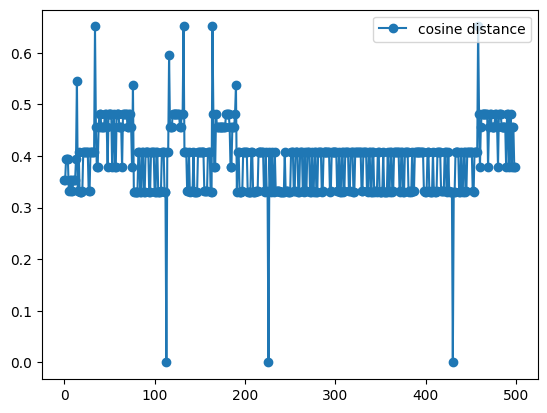

In [365]:
span = 4000
plt.plot(dis[span-500:span], '-o', label='cosine distance')
# plt.plot(mask[-span:], c='k', label = 'mask')
plt.legend()

In [361]:
data[:100]

'CABJFDEJABCJDEFJDEFJHGIJCBAJIGHJABCJABCJBACJHGIJFEDJGHIJIGHJCBAJDFEJDEFJFEDJFEDJBACJEFDJABCJCABJEDFJ'

In [366]:
seq[span-500:span]

'FEDEDFEFDFEFEDBACBCBACACACABACACACGIHIGHGIGIGHGIHGHGHIGHIHGHGIGIHGHGHGIGHGIHBCBCBCACBCACBCACACBCACACBCACBCBACACBCCACIGIGHGHGHGHGIGHGCACABACBABACBCBCACACACABABACACBCGHIHGIGIGIGIGIGHGHGIHIGIGHBCACBCBACACACBCBCACBCBABACACACABCABCCABCABCABABABCBCBCABABCBCACABACACBCACABCABACACBCABCACBCACACBACACACACBACACACABACBCACBACACABACACBCACACACABACACABCACBCACBABCACBCBACBCBCABCACBACACACABCACBCACACBABCABACACACACACABCBACABCBCABCBACACABABACABCABCBCCBCACACBCABCACBACACACABCACACGHIGHGHGHGHIGHGIGIGHGIHGHGIGIGIHGHIGHIGIHI'

In [707]:
marginals = [0]*len(tokens)

for token in seq:
    marginals[ord(token) - ord('A')] += 1

for ii in range(len(tokens)):
    marginals[ii] /= len(seq)

In [708]:
marginals

[0.136, 0.148, 0.152, 0.196, 0.154, 0.198, 0.016]

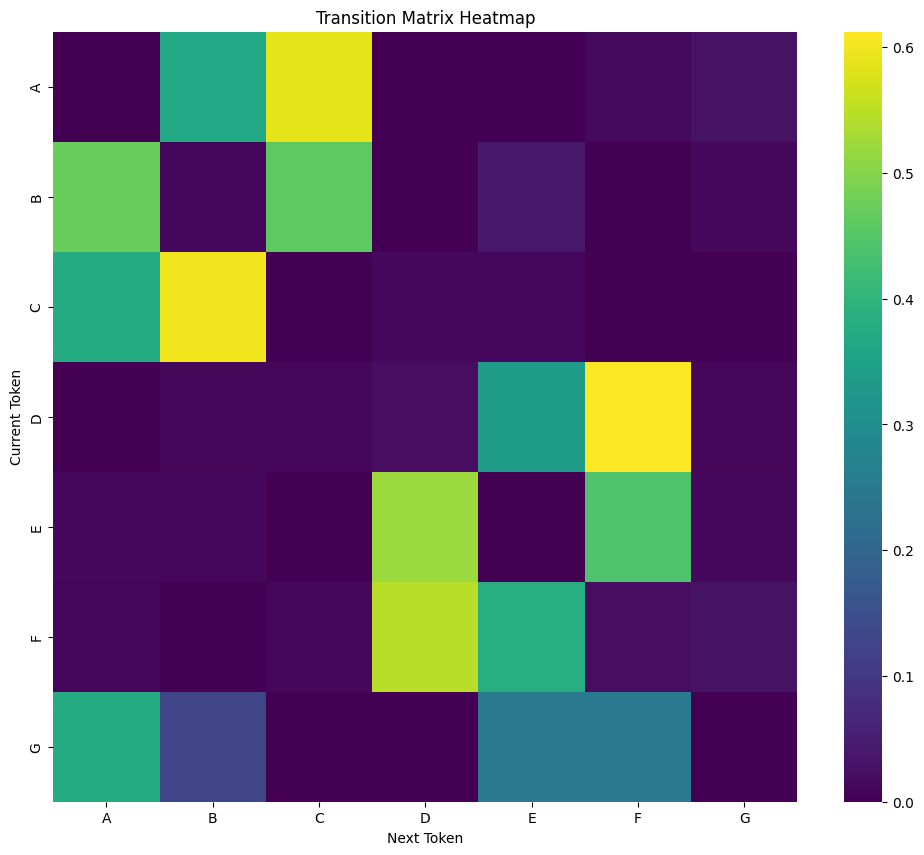

In [709]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

# Your sequence
sequence = seq

# Get unique characters
tokens = tokens
token_to_idx = {token: i for i, token in enumerate(tokens)}
idx_to_token = {i: token for token, i in token_to_idx.items()}

# Initialize transition matrix
n = len(tokens)
matrix = np.zeros((n, n), dtype=int)

# Count transitions
for i in range(len(sequence) - 1):
    a = token_to_idx[sequence[i]]
    b = token_to_idx[sequence[i+1]]
    matrix[a, b] += 1

# Normalize rows to probabilities
row_sums = matrix.sum(axis=1, keepdims=True)
transition_matrix = matrix / np.where(row_sums == 0, 1, row_sums)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(transition_matrix, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
plt.title("Transition Matrix Heatmap")
plt.xlabel("Next Token")
plt.ylabel("Current Token")
plt.show()


In [710]:
for ii in range(len(tokens)):
    transition_matrix[ii,:] *= marginals[ii]

In [711]:
transition_matrix

array([[0.        , 0.05      , 0.08      , 0.        , 0.        ,
        0.002     , 0.004     ],
       [0.07      , 0.002     , 0.068     , 0.        , 0.006     ,
        0.        , 0.002     ],
       [0.05674667, 0.0912    , 0.        , 0.00202667, 0.00202667,
        0.        , 0.        ],
       [0.        , 0.002     , 0.002     , 0.004     , 0.066     ,
        0.12      , 0.002     ],
       [0.002     , 0.002     , 0.        , 0.08      , 0.        ,
        0.068     , 0.002     ],
       [0.002     , 0.        , 0.002     , 0.108     , 0.076     ,
        0.004     , 0.006     ],
       [0.006     , 0.002     , 0.        , 0.        , 0.004     ,
        0.004     , 0.        ]])

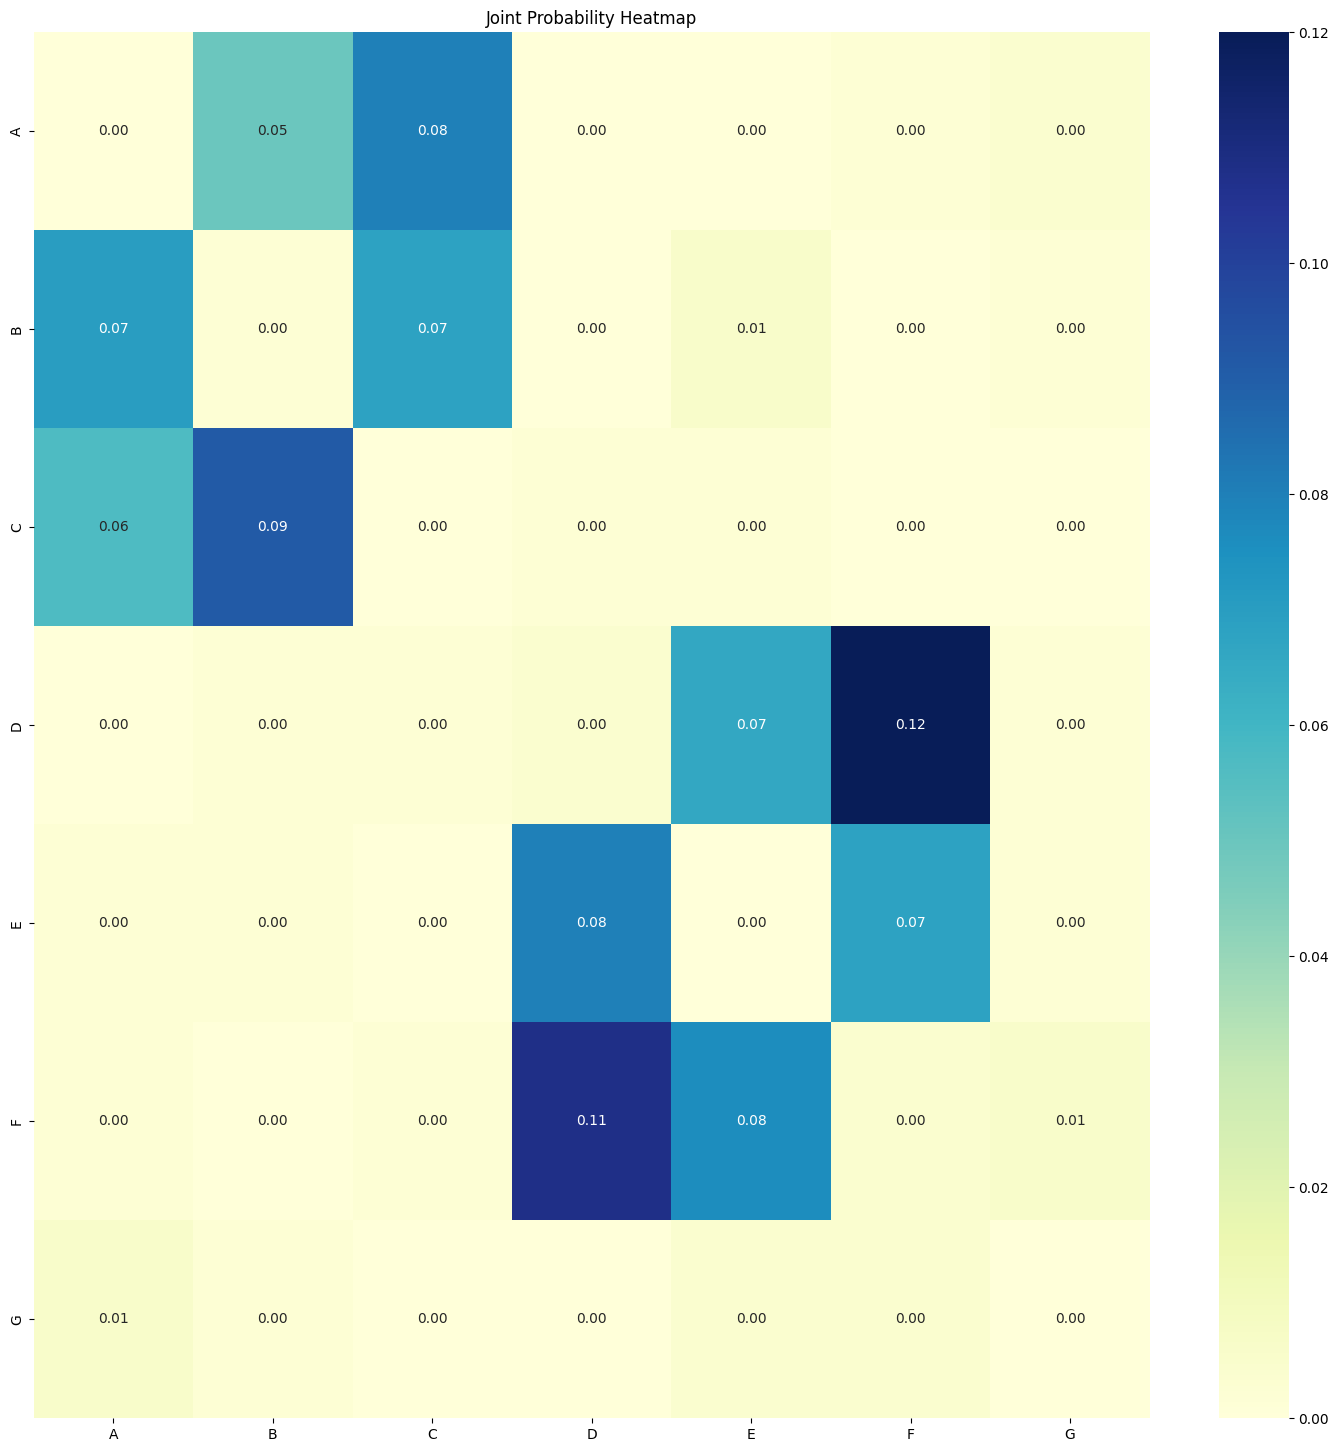

In [712]:
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pandas as pd
import numpy as np

# Define your transition matrix as a pandas DataFrame (use the one we computed before)
states = tokens
transition_data = transition_matrix
transition_df = pd.DataFrame(transition_data, index=states, columns=states)

### Heatmap
plt.figure(figsize=(18, 18))
sns.heatmap(transition_df, annot=True, cmap="YlGnBu", fmt=".2f", cbar=True)
plt.title("Joint Probability Heatmap")
plt.show()


In [332]:
(transition_matrix>np.mean(transition_matrix))*1

array([[0, 1, 1, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 0],
       [1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 1, 0, 1, 0],
       [0, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0]])

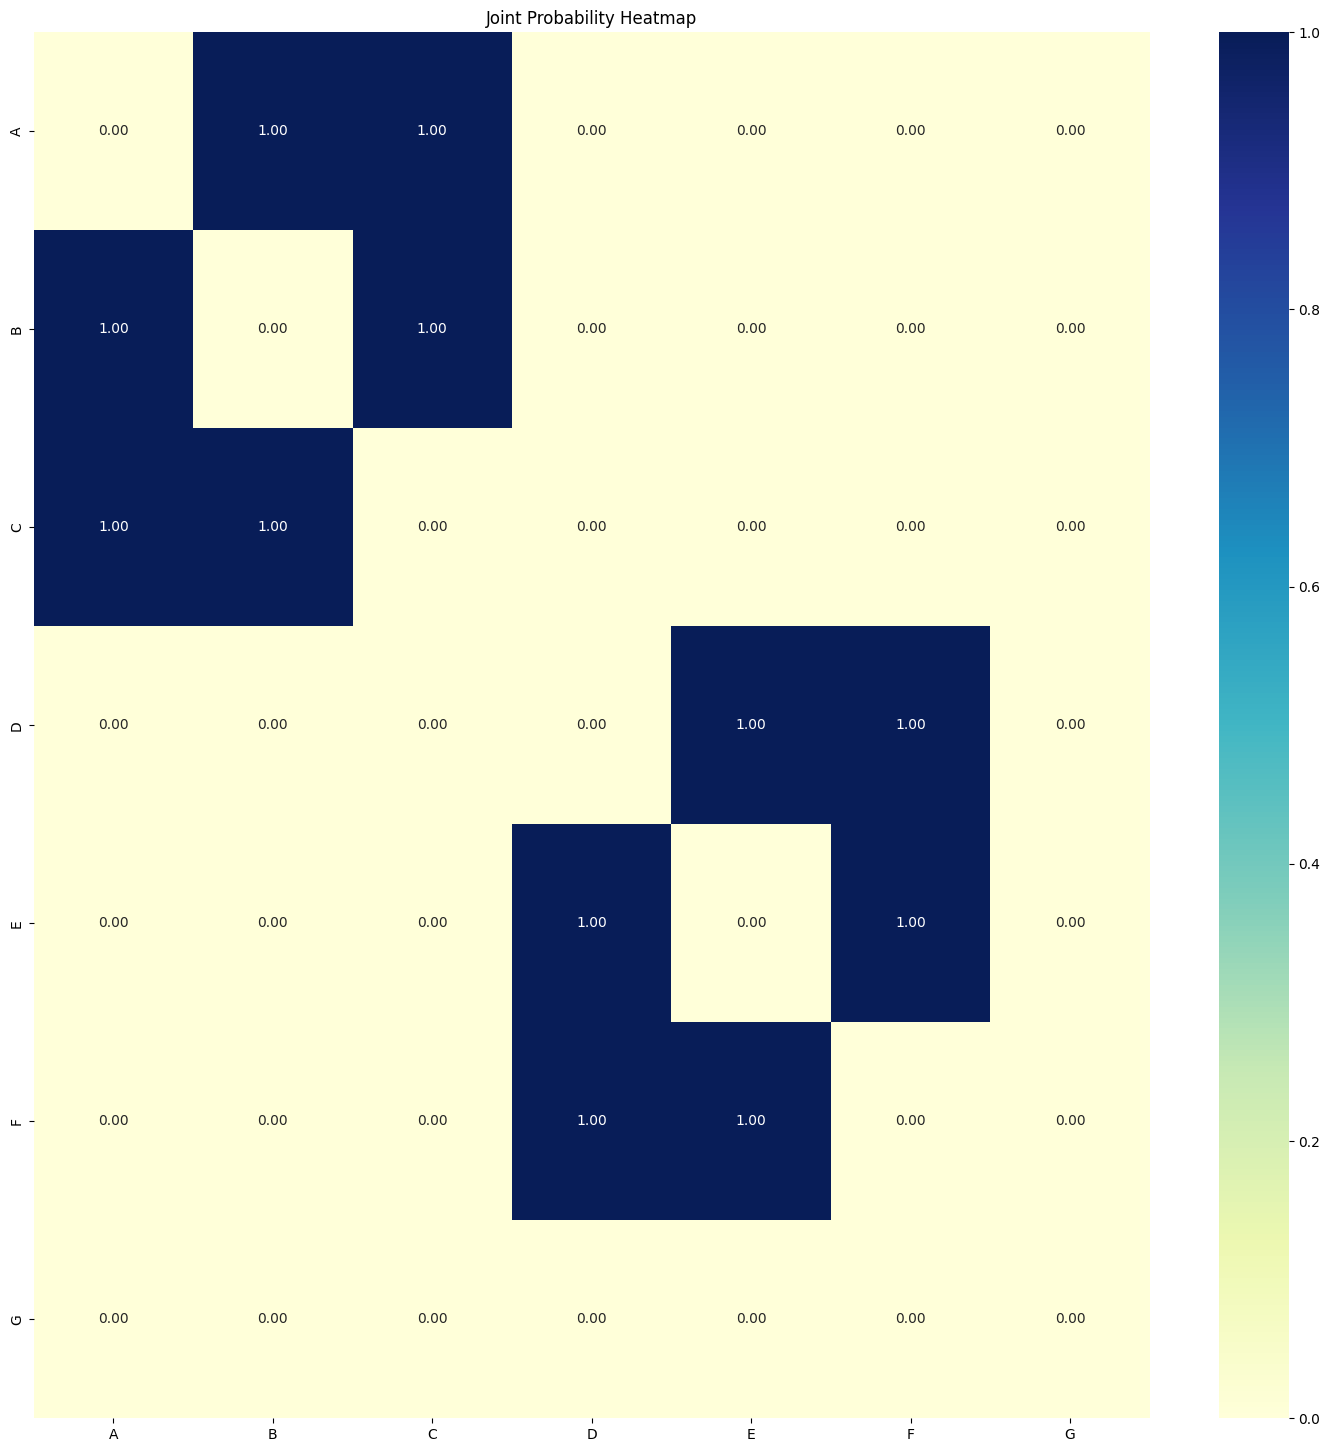

In [333]:
states = tokens
transition_data = (transition_matrix>np.mean(transition_matrix))*1
transition_df = pd.DataFrame(transition_data, index=states, columns=states)

### Heatmap
plt.figure(figsize=(18, 18))
sns.heatmap(transition_df, annot=True, cmap="YlGnBu", fmt=".2f", cbar=True)
plt.title("Joint Probability Heatmap")
plt.show()

In [358]:
class compressor(nn.Module):
    def __init__(self, input_size):
        super(compressor, self).__init__()
        self.fc = nn.Linear(input_size, input_size)
        

    def forward(self, x):
        out = self.fc(x)
        
        return out

    def freeze(self):
        self.fc.requires_grad = False

    def unfreeze(self):
        self.fc.requires_grad = True

In [424]:
class OnlineStats:
    def __init__(self):
        self.n = 0
        self.mean = 0.0
        self.M2 = 0.0  # sum of squares of differences from the current mean

    def update(self, x):
        self.n += 1
        delta = x - self.mean
        self.mean += delta / self.n
        delta2 = x - self.mean
        self.M2 += delta * delta2

    def get_mean(self):
        return self.mean

    def get_variance(self):
        if self.n < 2:
            return float('nan')
        return self.M2 / (self.n - 1)  # unbiased sample variance

    def get_std(self):
        return self.get_variance() ** 0.5

    def get_zscore(self, x):
        return (x - self.get_mean())/(self.get_std() + 1e-8)

In [448]:
total_replay_sample = 1000

idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
alpha = 0.2
stats_tracker = OnlineStats()
seq = ''
zscore = []

for jj in range(total_replay_sample):
    with torch.no_grad():
        # print(tokens[idx])
        if jj == 0:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1))
        else:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hidden_state)

        
        if jj == 0:
            prev_hidden = hidden_state.clone()
            moving_avg = hidden_state.clone()
        else:
            dis = compute_geodesic(prev_hidden, hidden_state)
            stats_tracker.update(dis)
            prev_hidden = hidden_state.clone()

            zscore.append(stats_tracker.get_zscore(dis))
            if stats_tracker.get_zscore(dis) > 1.5 and stats_tracker.n > 1:
                stats_tracker = OnlineStats()
                # print(seq[-1], jj)
                moving_avg = hidden_state.clone()
            else:
                moving_avg = (1-alpha)*moving_avg + alpha*hidden_state.clone()
            
        X_hat = torch.nn.functional.softmax(X_hat_, dim=1)
        
        dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()
        # print(X_hat, tokens[idx])
        
        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)

        seq = seq + tokens[idx]
        

In [449]:
seq[-4000:]

'DEFDFEFDFEDEFDFEFDEFEDFEFDFDEDEFEFEFEDEFFEFEFEDFFEDEFDFDEFDFEFDEFEDFEFEDFEFDFEDEDFEDFEDFEBACACBACACACBACBCACBCBACACBBCBCBCACABACACBCBACACBACBCBABCBCBACBCACBFEFEFDEDFEDFDFEFEFDFEFDFEFDFDEFEFEDEDFDFEDFEDFEFEDEFEFHIGIGIGIHGHGIHGHGHGHGHGHGHGHGHGIGIGHGHIABCABCACBACBCBCACBCACACBCBACABACACBCBCCBCACBACACACBABACACBCBACACABCACACBCACAABABACBABCBABCBCBCBCABACBABACBCBCACBACBCACBACBCBACACACBCBABABCBCABCABABCBCABCBCBACEDFDFDEDEEDFEFDFEDFEFDFDEDFDEFEFEFDFEGIGIGIGIHIGIGHGIGHIEFEDEDFDFEFDEDFDGIGIGHGIGIHGHGIHIGIGIGHGIHGIGIHGIHGHGIGIGIHGHGIHGCCACBCBCBACACBCGIGHGHBCBCBCBABACACACABCBEFDEFDFDFEFEFEDEDFDEFDFGHIGIGIGHGIGHGIHGHGIHGHGHGIGHIGIHGIGIHGHGIGHGHGHGHGIGHGIHIHGIGIHGIHGHIGIHIHGHGIGIGHIGHGIGIGHGIGFEDEDEFEFEFEFEFDFEFDEFEFDEFEDFDEDFEFDFEFEFDFDFDEFEFEDFDECBCBACACABACACBACACACBCBCBABCBCAIGIGIGHGIGIGHGFEFDEFEDEFEFEDEDFEFDFEFDFEFEFDFDFEFFEFEFEDEFEFEGHGHGIGIGHGIHGFDFEDFDFEFEFDEFEDFDFEDEFEFEFDFEDEDEFEFEFEDFEDEFEFEFEDFEFDFEFEFEFEDFDFEDFEDEDFDEDFEDFEFEFEDFEFEFDFEFEFDEDFEFEDFEDCACBCBACACBCACBCABACBACBACACBCABACACBC

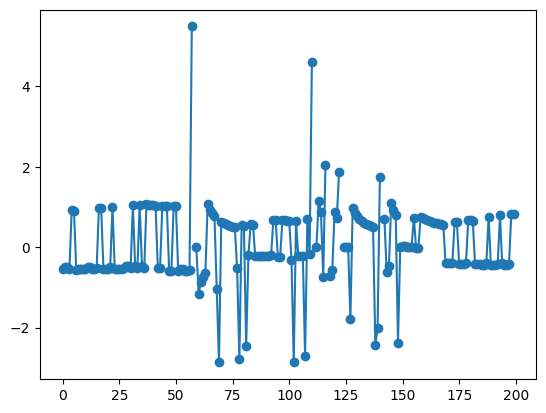

In [436]:
span = 200
plt.plot(zscore[-span:], '-o')


In [431]:
stats_tracker.get_mean()

np.float64(0.4365805613601981)

In [432]:
stats_tracker.get_std()

np.float64(0.08355190153930228)

In [434]:
stats_tracker.n

59

In [453]:
X.shape

torch.Size([1, 3, 10])

In [454]:
y.shape

torch.Size([1, 10])

In [457]:
data_set[0]

(tensor([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]))